### Baseline Model

Based on the EDA.ipynb we can safely start with a baseline of a yes/no model

- Input: Image and Question
- Output: Probability of yes or no

In [3]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 78.0 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=159e90ecebfeb5fd0f0cdc3338da61a990a000bf01fbff4628fe8f17641b50af
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [36]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm

import random
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import( classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModel

from datasets import load_dataset

In [8]:
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using: {device}")
    return device

set_seed(42)
device = get_device()

Using: cuda


In [9]:
ds = load_dataset("flaviagiammarino/vqa-rad")
train = ds["train"]
test = ds["test"]

def yes_no(example):
    return example["answer"].lower() in ["yes", "no"]

train_yn = train.filter(yes_no)
test_yn = test.filter(yes_no)

# Check the length of the datasets
print(len(train_yn), len(test_yn))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1793 [00:00<?, ? examples/s]

Filter:   0%|          | 0/451 [00:00<?, ? examples/s]

940 251


The number of Yes and No in the train and test are accurate

In [11]:
label_map = {"yes": 1, "no": 0}
train_yn = train_yn.map(lambda ex: {"label": label_map[ex["answer"].lower()]})
test_yn = test_yn.map(lambda ex: {"label": label_map[ex["answer"].lower()]})

Map:   0%|          | 0/940 [00:00<?, ? examples/s]

Map:   0%|          | 0/251 [00:00<?, ? examples/s]

In [ ]:
# Check the yes/no split in both sets
train_labels = [ex["label"] for ex in train_yn]
test_labels  = [ex["label"] for ex in test_yn]

print("Train:", Counter(train_labels))
print("Test: ", Counter(test_labels))

# As percentages
train_yes_pct = sum(train_labels) / len(train_labels)
test_yes_pct  = sum(test_labels)  / len(test_labels)
print(f"Train yes%: {train_yes_pct:.1%}")
print(f"Test  yes%: {test_yes_pct:.1%}")

Train: Counter({0: 473, 1: 467})
Test:  Counter({0: 133, 1: 118})
Train yes%: 49.7%
Test  yes%: 47.0%


Based on EDA
- Widths cluster roughly around 500–600 px and around 1000 px, with a few very large outliers
- Heights cluster around 400–800 px, with some up to around 1400 px

for the Baseline 224x224 is a standard size used by most CNNs such as ResNet

Downsizing from larger radiology images may:
- Loses some fine detail but for first experiments it is common to keep the compute cheap by keeping it to 224x224

We could be more careful by adding a CenterCrop

In [14]:
# Img_tranform with CenterCrop, ReSize and Normalize
# Because the images are of different sizes, we need to resize them to a fixed size before feeding them to the model
# We can use CenterCrop to crop the center of the image and then resize it to 224x224
# Then we can normalize the images using the mean and std of the ImageNet dataset
img_transform = transforms.Compose([
    transforms.Resize(512),
    transforms.CenterCrop(512),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [15]:
# text
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
text_model = AutoModel.from_pretrained("distilbert-base-uncased")
text_model.eval()
for p in text_model.parameters():
    p.requires_grad = False

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
class VQARADBinaryImageText(Dataset):
    def __init__(self, hf_split, img_tranform, tokenizer, text_model, max_length=32):
        self.data = hf_split
        self.img_transform = img_tranform
        self.tokenizer = tokenizer
        self.text_model = text_model
        self.max_length = max_length # Based on EDA most of the questions are short so for Baseline 32 should be good 

    def __len__(self):
        return len(self.data)

    # Tokenize the question and get the CLS token embedding as the question representation
    def encode_question(self, question):
        inputs = self.tokenizer(question,
                                return_tensors="pt",
                                truncation=True,
                                padding="max_length",
                                max_length=self.max_length)
        with torch.no_grad():
            outputs = self.text_model(**inputs)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # (1, hidden_size)
        return cls_embedding.squeeze(0)  # (hidden_size,)

    def __getitem__(self, idx):
        ex = self.data[idx]
        image = ex["image"]
        if self.img_transform:
            img_tensor = self.img_transform(image)  # (3, 224, 224)
        
        question = ex["question"]
        text_embedding = self.encode_question(question)  # (hidden_dim,)

        label = ex["label"]  # 0 or 1
        return img_tensor, text_embedding, label

In [17]:
# To check if the dataset class is working correctly
dataset = VQARADBinaryImageText(train_yn, img_transform, tokenizer, text_model)
img, text_emb, label = dataset[3]
print("img shape:", img.shape)
print("text_emb shape:", text_emb.shape)
print("label:", label)

img shape: torch.Size([3, 224, 224])
text_emb shape: torch.Size([768])
label: 1


Utilizing the computing power of my PC at home

In [18]:
train_dataset = VQARADBinaryImageText(train_yn, img_transform, tokenizer, text_model)
test_dataset = VQARADBinaryImageText(test_yn, img_transform, tokenizer, text_model)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Build CNN and a MLP over concatenated features

In [19]:
class ImageTextBinaryModel(nn.Module):
    def __init__(self, text_embedding_dim=768):
        """text_embedding_dim is the dimension of the text features from DistilBERT (768 for distilbert-base-uncased)"""
        super().__init__()
        # Image Branch of the model
        self.cnn = nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2))

        # After two max-pool layers, the feature map size will be (32, 56, 56) for 224x224 input
        self.img_feature_dim = 32 * 56 * 56  # After two max-pool layers on 224x224 input

        # Fusion and classification layers
        self.classifier = nn.Sequential(
            nn.Linear(self.img_feature_dim + text_embedding_dim, 256), # Fusion of image and text features
            nn.ReLU(),
            nn.Linear(256, 1)  # Binary classification
        )

    def forward(self, images, text_embeddings):
        """images: (B, 3, 224, 224), text_embeddings: (B, text_embedding_dim) and returns logits of shape (B,)"""
        x_img = self.cnn(images) # where images is (B, 3, 224, 224) B is batch size
        x_img = x_img.view(x_img.size(0), -1) # Flatten to (B, img_feature_dim) where img_feature_dim is 32*56*56
        x = torch.cat((x_img, text_embeddings), dim=1) # Concatenate image and text features (B, img_feature_dim + text_embedding_dim)
        logits = self.classifier(x) # (B, 1) where 1 is for binary classification
        return logits.squeeze(1) # Return (B,) for binary classification

Training Loop

In [28]:
model     = ImageTextBinaryModel().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, train_accs = [], []
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=True)

    for images, text_embs, labels in loop:
        images, text_embs, labels = (images.to(device),
                                     text_embs.to(device),
                                     labels.float().to(device))

        logits = model(images, text_embs)
        loss   = criterion(logits, labels)

        optimizer.zero_grad(); loss.backward(); optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds    = (torch.sigmoid(logits) > 0.5).long()
        correct += (preds.cpu() == labels.cpu().long()).sum().item()
        total   += labels.size(0)

        # live update inside the bar
        loop.set_postfix(loss=f"{running_loss/total:.4f}",
                         acc=f"{correct/total:.4f}")

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

Epoch 10/10: 100%|██████████| 59/59 [01:12<00:00,  1.23s/it, acc=0.8415, loss=0.3388]


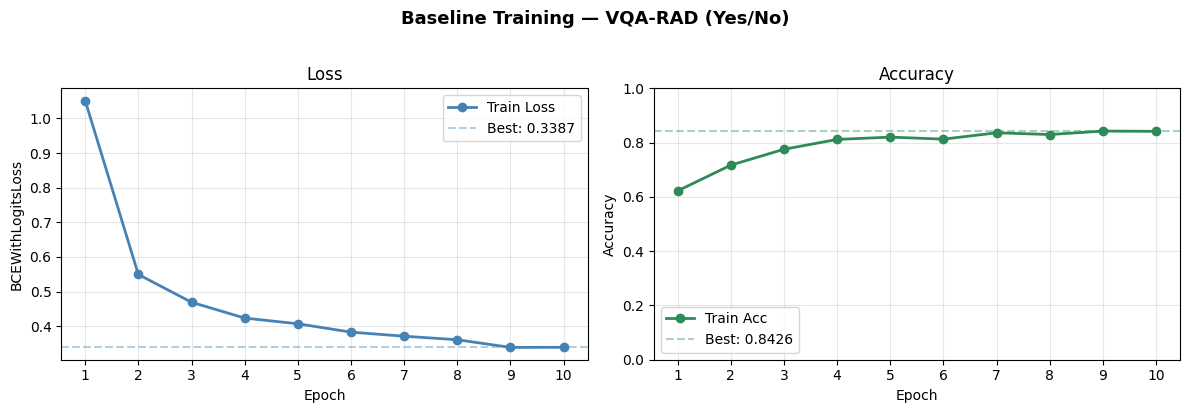

In [29]:
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Baseline Training — VQA-RAD (Yes/No)", fontsize=13, fontweight='bold', y=1.02)

# Loss
ax1.plot(epochs, train_losses, marker='o', linewidth=2, color='steelblue', label='Train Loss')
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCEWithLogitsLoss")
ax1.set_xticks(epochs)
ax1.axhline(min(train_losses), color='steelblue', linestyle='--', alpha=0.4,
            label=f"Best: {min(train_losses):.4f}")
ax1.legend(); ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs, train_accs, marker='o', linewidth=2, color='seagreen', label='Train Acc')
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_xticks(epochs)
ax2.set_ylim(0, 1)
ax2.axhline(max(train_accs), color='seagreen', linestyle='--', alpha=0.4,
            label=f"Best: {max(train_accs):.4f}")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

Evaluation collecting all the predictions

In [30]:
model.eval()
all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, text_embs, labels in test_loader:
        logits = model(images.to(device), text_embs.to(device))
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs > 0.5).astype(int)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

print(classification_report(all_labels, all_preds, target_names=["No", "Yes"]))
print(f"AUC-ROC:  {roc_auc_score(all_labels, all_probs):.4f}")
print(f"Avg Prec: {average_precision_score(all_labels, all_probs):.4f}")

              precision    recall  f1-score   support

          No       0.65      0.62      0.63       133
         Yes       0.59      0.63      0.61       118

    accuracy                           0.62       251
   macro avg       0.62      0.62      0.62       251
weighted avg       0.62      0.62      0.62       251

AUC-ROC:  0.6456
Avg Prec: 0.6099


Confusion Matrix

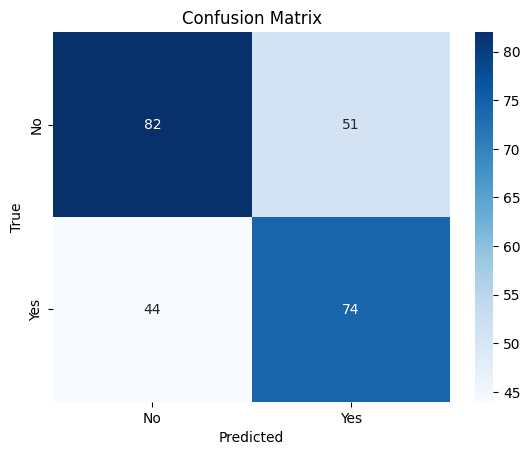

In [31]:
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No","Yes"], yticklabels=["No","Yes"])
plt.title("Confusion Matrix"); plt.ylabel("True"); plt.xlabel("Predicted")
plt.show()

ROC and PR Curves

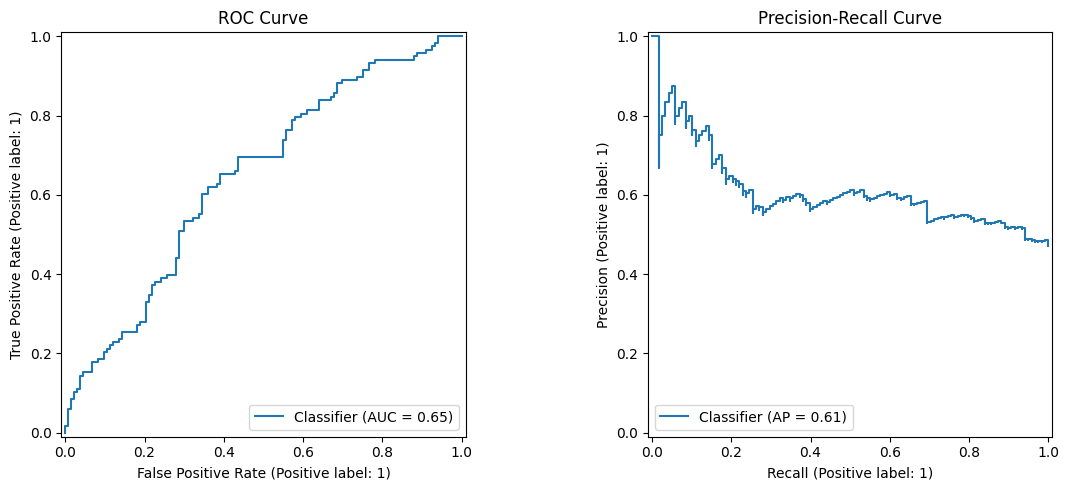

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(all_labels, all_probs, ax=ax1)
PrecisionRecallDisplay.from_predictions(all_labels, all_probs, ax=ax2)
ax1.set_title("ROC Curve"); ax2.set_title("Precision-Recall Curve")
plt.tight_layout(); plt.show()

Confidence Distribution

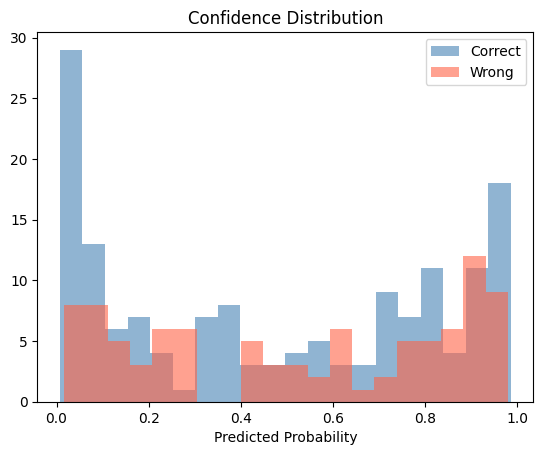

In [33]:
correct_probs = [p for p, t, pr in zip(all_probs, all_labels, all_preds) if t == pr]
wrong_probs   = [p for p, t, pr in zip(all_probs, all_labels, all_preds) if t != pr]

plt.hist(correct_probs, bins=20, alpha=0.6, label='Correct', color='steelblue')
plt.hist(wrong_probs,   bins=20, alpha=0.6, label='Wrong',   color='tomato')
plt.xlabel("Predicted Probability"); plt.title("Confidence Distribution")
plt.legend(); plt.show()

Error Analysis

In [35]:
errors = [(i, t, pr, p) for i, (t, pr, p)
          in enumerate(zip(all_labels, all_preds, all_probs)) if t != pr]

print(f"Total errors: {len(errors)}\n")
for idx, true, pred, prob in errors[:5]:
    ex = test_yn[idx]
    print(f"Q: {ex['question']}")
    print(f"   True: {'Yes' if true else 'No'} | Pred: {'Yes' if pred else 'No'} | Conf: {prob:.3f}\n")

Total errors: 95

Q: is there evidence of an aortic aneurysm?
   True: Yes | Pred: No | Conf: 0.026

Q: is there airspace consolidation on the left side?
   True: Yes | Pred: No | Conf: 0.252

Q: is there any intraparenchymal abnormalities in the lung fields?
   True: No | Pred: Yes | Conf: 0.548

Q: are the kidneys present in this image?
   True: No | Pred: Yes | Conf: 0.809

Q: is the liver visible in the image?
   True: No | Pred: Yes | Conf: 0.529



In [49]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = "/content/drive/MyDrive/ml-project-example"
os.makedirs(f"{BASE_DIR}/data/04-predictions", exist_ok=True)
os.makedirs(f"{BASE_DIR}/data/05-models", exist_ok=True)

pd.DataFrame({
    "true_label":  all_labels,
    "predicted":   all_preds,
    "probability": all_probs
}).to_csv(f"{BASE_DIR}/data/04-predictions/baseline_test_predictions.csv", index=False)

torch.save(model.state_dict(), f"{BASE_DIR}/data/05-models/baseline_image_text_binary.pt")

print("Saved to Drive ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Drive ✅
